In [3]:
import warnings
# Suppress the specific SciPy/NumPy version warnings
warnings.filterwarnings('ignore', message='.*NumPy version.*')

In [4]:
# %%
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Step 1: Loading Processed Data...")

DATA_PROCESSED = os.path.join("..", "data", "processed")
file_path = os.path.join(DATA_PROCESSED, "processed_all_households_blind.csv")

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Missing {file_path}. Please run the 02_data_processing notebook first.")

df = pd.read_csv(file_path)
print(f"[SUCCESS] Loaded dataset: {df.shape[0]} households.")
print(f"[SUCCESS] Class Distribution:\n{df['TARGET_GAP'].value_counts(normalize=True)*100}")

Step 1: Loading Processed Data...
[SUCCESS] Loaded dataset: 61071 households.
[SUCCESS] Class Distribution:
TARGET_GAP
0    91.929066
1     8.070934
Name: proportion, dtype: float64


In [ ]:
# %%
print("Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...")

# Define features (X) and target (y)
# We drop SERIALNO (ID) and PUMA (Geography) as they are not standard numerical proxies. Also drop poverty gap as it is directly related
X = df.drop(columns=['SERIALNO', 'PUMA', 'TARGET_GAP','POVERTY_GAP'])
y = df['TARGET_GAP']

# 1st Split: 70% Train, 30% Temporary Holdout (Val + Test)
# stratify=y ensures the small "Gap" class is distributed evenly across the splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2nd Split: Split the 30% holdout exactly in half (15% Validate, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"[SUCCESS] Training set:   {X_train.shape[0]} rows")
print(f"[SUCCESS] Validation set: {X_val.shape[0]} rows")
print(f"[SUCCESS] Test set:       {X_test.shape[0]} rows")

Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...
[SUCCESS] Training set:   42749 rows
[SUCCESS] Validation set: 9161 rows
[SUCCESS] Test set:       9161 rows


In [6]:
# %%
print("Step 3: Scaling Features and Training Baseline Model...")

# Features like NUM_CHILDREN (0-5) and GRPIP (Rent % 0-100) are on different scales.
# Logistic Regression requires them to be standardized.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage from the validation/test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize the model
# class_weight='balanced' is critical here. Since the Gap is a minority class in the general population,
# this forces the model to heavily penalize missing a Gap household.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("[SUCCESS] Logistic Regression Model trained successfully!")

Step 3: Scaling Features and Training Baseline Model...
[SUCCESS] Logistic Regression Model trained successfully!


Step 4: Evaluating on Validation Set...

--- Classification Report ---
                precision    recall  f1-score   support

Not in Gap (0)       0.99      0.80      0.88      8421
   The Gap (1)       0.28      0.88      0.42       740

      accuracy                           0.81      9161
     macro avg       0.63      0.84      0.65      9161
  weighted avg       0.93      0.81      0.85      9161

--- ROC-AUC Score ---
0.9068



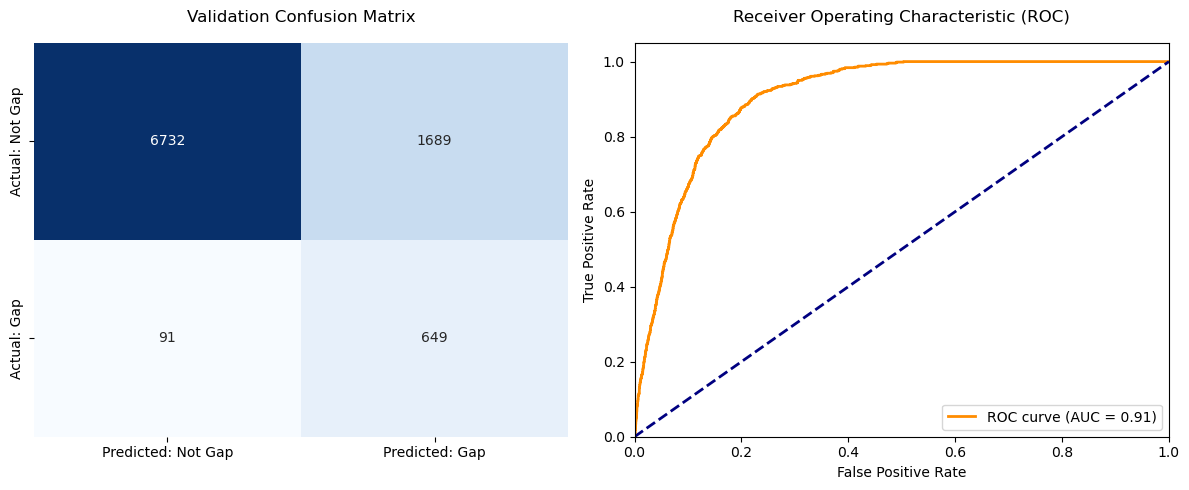

In [7]:
# %%
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 4: Evaluating on Validation Set...")

# Predict classes (0 or 1) and probabilities (for ROC-AUC)
y_val_pred = model.predict(X_val_scaled)
y_val_probs = model.predict_proba(X_val_scaled)[:, 1] # Get probabilities for Class 1 (The Gap)

# 1. Classification Report
print("\n--- Classification Report ---")
# 0 = Not in Gap, 1 = The Gap
print(classification_report(y_val, y_val_pred, target_names=["Not in Gap (0)", "The Gap (1)"]))

# 2. ROC-AUC Score
auc_score = roc_auc_score(y_val, y_val_probs)
print(f"--- ROC-AUC Score ---\n{auc_score:.4f}\n")

# 3. Visualizations: Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted: Not Gap", "Predicted: Gap"],
            yticklabels=["Actual: Not Gap", "Actual: Gap"], ax=axes[0])
axes[0].set_title('Validation Confusion Matrix', pad=15)

# Plot B: ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random-guess line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)', pad=15)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Step 5: Analyzing the Proxies (What predicts the Gap?)

POSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.
NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.



,Feature,Coefficient
10,NP,3.418275
15,WORKERS_PC,1.917571
12,LOW_INCOME_FLAG,0.898875
13,RENT_BURDEN,0.343899
14,IS_OWNER,0.319999
8,GRPIP,0.164372
7,ACCESSINET,0.123529
9,RMSP,0.098656
24,AMENITY_COUNT,0.083028
28,PERSONS_PER_ROOM,0.083024


/var/folders/7d/w3k4x21n7vn2gzcm8yfb8vdw0000gn/T/ipykernel_37238/3643547163.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=df_coef, palette='coolwarm')


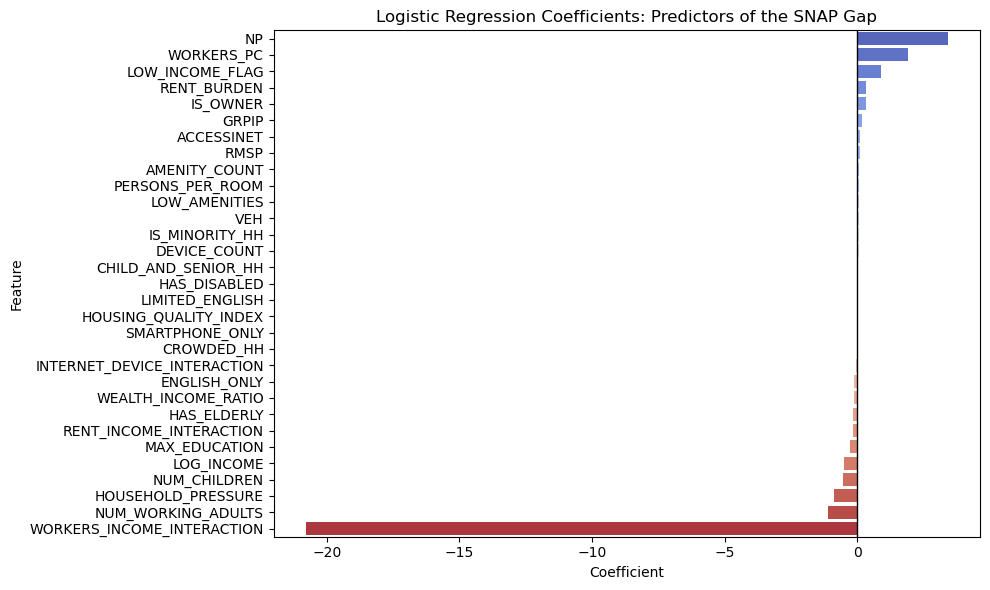

In [8]:
# %%
print("Step 5: Analyzing the Proxies (What predicts the Gap?)")

# Extract coefficients and map them back to the original feature names
coefficients = model.coef_[0]
feature_names = X.columns

# Create a clean DataFrame
df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by impact
df_coef = df_coef.sort_values(by='Coefficient', ascending=False)

print("\nPOSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.")
print("NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.\n")

display(df_coef)

# Optional Visual Plot of the Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=df_coef, palette='coolwarm')
plt.title('Logistic Regression Coefficients: Predictors of the SNAP Gap')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [9]:
# %%
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

print("[INIT] Step 6: Setting up Advanced Models and Validation Split...")

# To tune specifically on the validation set without cross-validation leakage,
# we combine the train and validation sets and use PredefinedSplit.
X_tune = np.vstack((X_train_scaled, X_val_scaled))
y_tune = np.concatenate((y_train, y_val))

# Create a list where -1 means "Training Data" and 0 means "Validation Data"
test_fold = [-1] * len(X_train_scaled) + [0] * len(X_val_scaled)
ps = PredefinedSplit(test_fold)

print("[SUCCESS] PredefinedSplit created. Training rows:", len(X_train_scaled), "| Validation rows:", len(X_val_scaled))

[INIT] Step 6: Setting up Advanced Models and Validation Split...
[SUCCESS] PredefinedSplit created. Training rows: 42749 | Validation rows: 9161


In [13]:
# %%
print("[PROCESS] Step 7: Tuning Random Forest Classifier...")

# Define the baseline model (balanced weights are critical here)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Define the hyperparameter grid to search
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Setup RandomizedSearch optimizing for ROC-AUC
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=15,               # Number of random combinations to try
    scoring='roc_auc',       # Optimize for the area under the ROC curve
    cv=ps,                   # Use our explicit Validation set
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

rf_search.fit(X_tune, y_tune)

best_rf = rf_search.best_estimator_
print(f"\n[SUCCESS] Best Random Forest AUC on Validation: {rf_search.best_score_:.4f}")
print(f"[INFO] Best RF Parameters: {rf_search.best_params_}")

[PROCESS] Step 7: Tuning Random Forest Classifier...
Fitting 1 folds for each of 15 candidates, totalling 15 fits

[SUCCESS] Best Random Forest AUC on Validation: 0.9423
[INFO] Best RF Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}


In [14]:
# %%
print("[PROCESS] Step 8: Tuning LightGBM Classifier...")

# LightGBM handles class imbalance using the 'is_unbalance' parameter
lgb_base = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1)

# Define the hyperparameter grid
# LightGBM is prone to overfitting, so we control num_leaves and depth
lgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 50],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_grid,
    n_iter=20,               
    scoring='roc_auc',       
    cv=ps,                   
    random_state=42,
    verbose=1
)

lgb_search.fit(X_tune, y_tune)

best_lgb = lgb_search.best_estimator_
print(f"\n[SUCCESS] Best LightGBM AUC on Validation: {lgb_search.best_score_:.4f}")
print(f"[INFO] Best LGBM Parameters: {lgb_search.best_params_}")

[PROCESS] Step 8: Tuning LightGBM Classifier...
Fitting 1 folds for each of 20 candidates, totalling 20 fits
[LightGBM] [Info] Number of positive: 3450, number of negative: 39299
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1420
[LightGBM] [Info] Number of data points in the train set: 42749, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080704 -> initscore=-2.432825
[LightGBM] [Info] Start training from score -2.432825


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3450, number of negative: 39299
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1420
[LightGBM] [Info] Number of data points in the train set: 42749, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080704 -> initscore=-2.432825
[LightGBM] [Info] Start training from score -2.432825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3450, number of negative: 39299
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1420
[LightGBM] [Info] Number of data points in the train set: 42749, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080704 -> initscore=-2.432825
[LightGBM] [Info] Start training from score -2.432825


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 4190, number of negative: 47720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

[SUCCESS] Best LightGBM AUC on Validation: 0.9455
[INFO] Best LGBM Parameters: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [12]:
# %%
print("[EVAL] Step 9: Comparing Champion Models on the Validation Set...")

# We calculate the ROC-AUC for all three models (Logistic, RF, LightGBM)
# using the predict_proba method to get probability scores for Class 1.

# 1. Logistic Regression (Baseline)
y_val_probs_lr = model.predict_proba(X_val_scaled)[:, 1]
auc_lr = roc_auc_score(y_val, y_val_probs_lr)

# 2. Random Forest (Tuned)
y_val_probs_rf = best_rf.predict_proba(X_val_scaled)[:, 1]
auc_rf = roc_auc_score(y_val, y_val_probs_rf)

# 3. LightGBM (Tuned)
y_val_probs_lgb = best_lgb.predict_proba(X_val_scaled)[:, 1]
auc_lgb = roc_auc_score(y_val, y_val_probs_lgb)

print("\n--- ROC-AUC Comparison ---")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Random Forest:       {auc_rf:.4f}")
print(f"LightGBM:            {auc_lgb:.4f}")

# Identify the winner
models_dict = {'Logistic Regression': auc_lr, 'Random Forest': auc_rf, 'LightGBM': auc_lgb}
champion_name = max(models_dict, key=models_dict.get)
print(f"\n[CHAMPION] The best performing model is: {champion_name}")

[EVAL] Step 9: Comparing Champion Models on the Validation Set...

--- ROC-AUC Comparison ---
Logistic Regression: 0.9068
Random Forest:       0.9793
LightGBM:            0.9602

[CHAMPION] The best performing model is: Random Forest


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
